# 01 - Data Loading and EDA

In this notebook, we load the gold price dataset, inspect its structure, clean the date column, and perform initial exploratory data analysis.

## Import Libraries

In [68]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

## Load Dataset

In [69]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "FINAL_USO.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
0,2011-12-15,154.740005,154.949997,151.710007,152.330002,152.330002,21521900,123.029999,123.199997,121.989998,...,51.570000,51.680000,48.973877,20605600,36.900002,36.939999,36.049999,36.130001,36.130001,12616700
1,2011-12-16,154.309998,155.369995,153.899994,155.229996,155.229996,18124300,122.230003,122.949997,121.300003,...,52.040001,52.680000,49.921513,16285400,36.180000,36.500000,35.730000,36.270000,36.270000,12578800
2,2011-12-19,155.479996,155.860001,154.360001,154.869995,154.869995,12547200,122.059998,122.320000,120.029999,...,51.029999,51.169998,48.490578,15120200,36.389999,36.450001,35.930000,36.200001,36.200001,7418200
3,2011-12-20,156.820007,157.429993,156.580002,156.979996,156.979996,9136300,122.180000,124.139999,120.370003,...,52.369999,52.990002,50.215282,11644900,37.299999,37.610001,37.220001,37.560001,37.560001,10041600
4,2011-12-21,156.979996,157.529999,156.130005,157.160004,157.160004,11996100,123.930000,124.360001,122.750000,...,52.419998,52.959999,50.186852,8724300,37.669998,38.240002,37.520000,38.110001,38.110001,10728000


## Check Data Types

In [70]:
df.dtypes

Date              object
Open             float64
High             float64
Low              float64
Close            float64
                  ...   
USO_High         float64
USO_Low          float64
USO_Close        float64
USO_Adj Close    float64
USO_Volume         int64
Length: 81, dtype: object

The `Date` column is loaded as an object, so we convert it to datetime format and sort the data chronologically.

In [71]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
0,2011-12-15,154.740005,154.949997,151.710007,152.330002,152.330002,21521900,123.029999,123.199997,121.989998,...,51.570000,51.680000,48.973877,20605600,36.900002,36.939999,36.049999,36.130001,36.130001,12616700
1,2011-12-16,154.309998,155.369995,153.899994,155.229996,155.229996,18124300,122.230003,122.949997,121.300003,...,52.040001,52.680000,49.921513,16285400,36.180000,36.500000,35.730000,36.270000,36.270000,12578800
2,2011-12-19,155.479996,155.860001,154.360001,154.869995,154.869995,12547200,122.059998,122.320000,120.029999,...,51.029999,51.169998,48.490578,15120200,36.389999,36.450001,35.930000,36.200001,36.200001,7418200
3,2011-12-20,156.820007,157.429993,156.580002,156.979996,156.979996,9136300,122.180000,124.139999,120.370003,...,52.369999,52.990002,50.215282,11644900,37.299999,37.610001,37.220001,37.560001,37.560001,10041600
4,2011-12-21,156.979996,157.529999,156.130005,157.160004,157.160004,11996100,123.930000,124.360001,122.750000,...,52.419998,52.959999,50.186852,8724300,37.669998,38.240002,37.520000,38.110001,38.110001,10728000


## Basic Information

In [72]:
print("Rows and columns:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Rows and columns: (1718, 81)
Date range: 2011-12-15 00:00:00 to 2018-12-31 00:00:00


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1718 entries, 0 to 1717
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1718 non-null   datetime64[ns]
 1   Open           1718 non-null   float64       
 2   High           1718 non-null   float64       
 3   Low            1718 non-null   float64       
 4   Close          1718 non-null   float64       
 5   Adj Close      1718 non-null   float64       
 6   Volume         1718 non-null   int64         
 7   SP_open        1718 non-null   float64       
 8   SP_high        1718 non-null   float64       
 9   SP_low         1718 non-null   float64       
 10  SP_close       1718 non-null   float64       
 11  SP_Ajclose     1718 non-null   float64       
 12  SP_volume      1718 non-null   int64         
 13  DJ_open        1718 non-null   float64       
 14  DJ_high        1718 non-null   float64       
 15  DJ_low         1718 n

## Missing Values

In [74]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

## Duplicate Dates

In [75]:
df["Date"].duplicated().sum()

0

## Summary Statistics

In [76]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1718,2015-07-06 19:29:15.995343360,2011-12-15 00:00:00,2013-10-03 06:00:00,2015-07-18 12:00:00,2017-04-09 06:00:00,2018-12-31 00:00:00,NaN
Open,1718.0,127.323434,100.919998,116.220001,121.915001,128.427494,173.199997,17.526993
High,1718.0,127.854237,100.989998,116.540001,122.325001,129.087498,174.070007,17.631189
Low,1718.0,126.777695,100.230003,115.739998,121.369999,127.840001,172.919998,17.396513
Close,1718.0,127.319482,100.5,116.052502,121.795002,128.470001,173.610001,17.536269
...,...,...,...,...,...,...,...,...
USO_High,1718.0,22.307148,8.03,11.5,16.635001,34.667499,42.299999,11.478671
USO_Low,1718.0,21.904657,7.67,11.3,16.04,34.11,41.299999,11.373997
USO_Close,1718.0,22.109051,7.96,11.3925,16.345,34.417499,42.009998,11.432787
USO_Adj Close,1718.0,22.109051,7.96,11.3925,16.345,34.417499,42.009998,11.432787


## Gold Price Trend

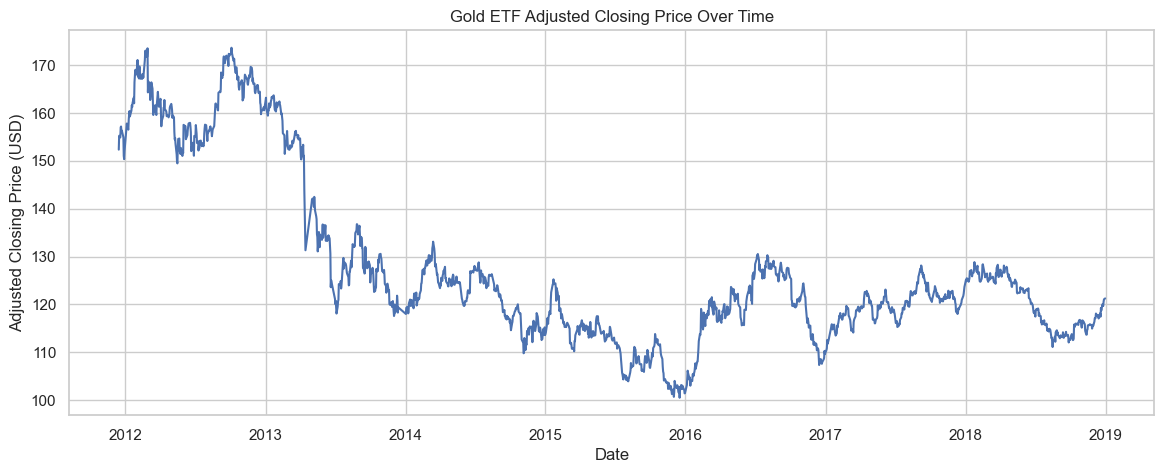

In [77]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Adj Close"])
plt.title("Gold ETF Adjusted Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price (USD)")
plt.show()

The adjusted closing price of the gold ETF shows a strong decline from 2012 to 2015, followed by a more stable movement between 2016 and 2018. The price fluctuates over time, indicating visible trends and market volatility.

## Create Target for Later Modeling

In [78]:
df["target_next_price"] = df["Adj Close"].shift(-1)

df[["Date", "Adj Close", "target_next_price"]].head()

,Date,Adj Close,target_next_price
0,2011-12-15,152.330002,155.229996
1,2011-12-16,155.229996,154.869995
2,2011-12-19,154.869995,156.979996
3,2011-12-20,156.979996,157.160004
4,2011-12-21,157.160004,156.039993


In [79]:
# The final row has no next-day price, so target_next_price will be missing there.
df[["Date", "Adj Close", "target_next_price"]].tail()

,Date,Adj Close,target_next_price
1713,2018-12-24,120.019997,119.660004
1714,2018-12-26,119.660004,120.570000
1715,2018-12-27,120.570000,121.059998
1716,2018-12-28,121.059998,121.250000
1717,2018-12-31,121.250000,NaN


## Correlation With Target

In [80]:
# Drop the last row before correlation because target_next_price is missing there.
eda_df = df.dropna(subset=["target_next_price"]).copy()

numeric_df = eda_df.select_dtypes(include="number")

correlation_with_target = (
    numeric_df
    .corr()["target_next_price"]
    .sort_values(ascending=False)
    .reset_index()
)

correlation_with_target.columns = ["feature", "correlation_with_target_next_price"]

correlation_with_target

,feature,correlation_with_target_next_price
0,target_next_price,1.000000
1,Close,0.997438
2,Adj Close,0.997438
3,High,0.997058
4,Low,0.996982
...,...,...
76,SP_high,-0.684863
77,USDI_High,-0.718172
78,USDI_Open,-0.718363
79,USDI_Price,-0.719671


## Select Important Features Based on Correlation

In [81]:
# Remove the target itself from the correlation table
important_features = correlation_with_target[
    correlation_with_target["feature"] != "target_next_price"
].copy()

# Select features with strong absolute correlation with target
important_features = important_features[
    important_features["correlation_with_target_next_price"].abs() >= 0.5
]

print("Shape: ", important_features.shape)

important_features

Shape:  (56, 2)


,feature,correlation_with_target_next_price
1,Close,0.997438
2,Adj Close,0.997438
3,High,0.997058
4,Low,0.996982
5,Open,0.996540
6,GDX_Low,0.974766
7,GDX_Close,0.974697
8,GDX_High,0.974492
9,GDX_Adj Close,0.974198
10,GDX_Open,0.974088


## Correlation Among Important Independent Variables

In [82]:
selected_features = important_features["feature"].tolist()

selected_corr = eda_df[selected_features].corr()

selected_corr

,Close,Adj Close,High,Low,Open,GDX_Low,GDX_Close,GDX_High,GDX_Adj Close,GDX_Open,...,DJ_open,SP_Ajclose,SP_low,SP_close,SP_open,SP_high,USDI_High,USDI_Open,USDI_Price,USDI_Low
Close,1.000000,1.000000,0.999535,0.999532,0.998976,0.975570,0.975466,0.975265,0.974983,0.974835,...,-0.588845,-0.666129,-0.683773,-0.684314,-0.684646,-0.684930,-0.720020,-0.720141,-0.721566,-0.722078
Adj Close,1.000000,1.000000,0.999535,0.999532,0.998976,0.975570,0.975466,0.975265,0.974983,0.974835,...,-0.588845,-0.666129,-0.683773,-0.684314,-0.684646,-0.684930,-0.720020,-0.720141,-0.721566,-0.722078
High,0.999535,0.999535,1.000000,0.999262,0.999515,0.975657,0.975346,0.975729,0.974747,0.975437,...,-0.592488,-0.669701,-0.687337,-0.687835,-0.688134,-0.688380,-0.721122,-0.721446,-0.722561,-0.723363
Low,0.999532,0.999532,0.999262,1.000000,0.999442,0.975347,0.974576,0.974597,0.974185,0.974737,...,-0.585066,-0.662383,-0.680012,-0.680597,-0.680939,-0.681268,-0.719436,-0.719515,-0.720682,-0.721186
Open,0.998976,0.998976,0.999515,0.999442,1.000000,0.975486,0.974601,0.975150,0.974100,0.975519,...,-0.588650,-0.665837,-0.683480,-0.684020,-0.684334,-0.684615,-0.720004,-0.720345,-0.721125,-0.721964
GDX_Low,0.975570,0.975570,0.975657,0.975347,0.975486,1.000000,0.999487,0.999419,0.999208,0.999514,...,-0.601853,-0.670909,-0.688943,-0.690088,-0.690507,-0.691466,-0.667272,-0.667602,-0.668662,-0.669441
GDX_Close,0.975466,0.975466,0.975346,0.974576,0.974601,0.999487,1.000000,0.999520,0.999656,0.998829,...,-0.605856,-0.674371,-0.692529,-0.693564,-0.694093,-0.694965,-0.666477,-0.666803,-0.668113,-0.668863
GDX_High,0.975265,0.975265,0.975729,0.974597,0.975150,0.999419,0.999520,1.000000,0.999041,0.999523,...,-0.610581,-0.678869,-0.696985,-0.698054,-0.698419,-0.699294,-0.667211,-0.667726,-0.668721,-0.669711
GDX_Adj Close,0.974983,0.974983,0.974747,0.974185,0.974100,0.999208,0.999656,0.999041,1.000000,0.998428,...,-0.588952,-0.657778,-0.676424,-0.677471,-0.678034,-0.678919,-0.657150,-0.657364,-0.658703,-0.659331
GDX_Open,0.974835,0.974835,0.975437,0.974737,0.975519,0.999514,0.998829,0.999523,0.998428,1.000000,...,-0.606282,-0.674941,-0.692974,-0.694118,-0.694408,-0.695366,-0.667099,-0.667629,-0.668346,-0.669391


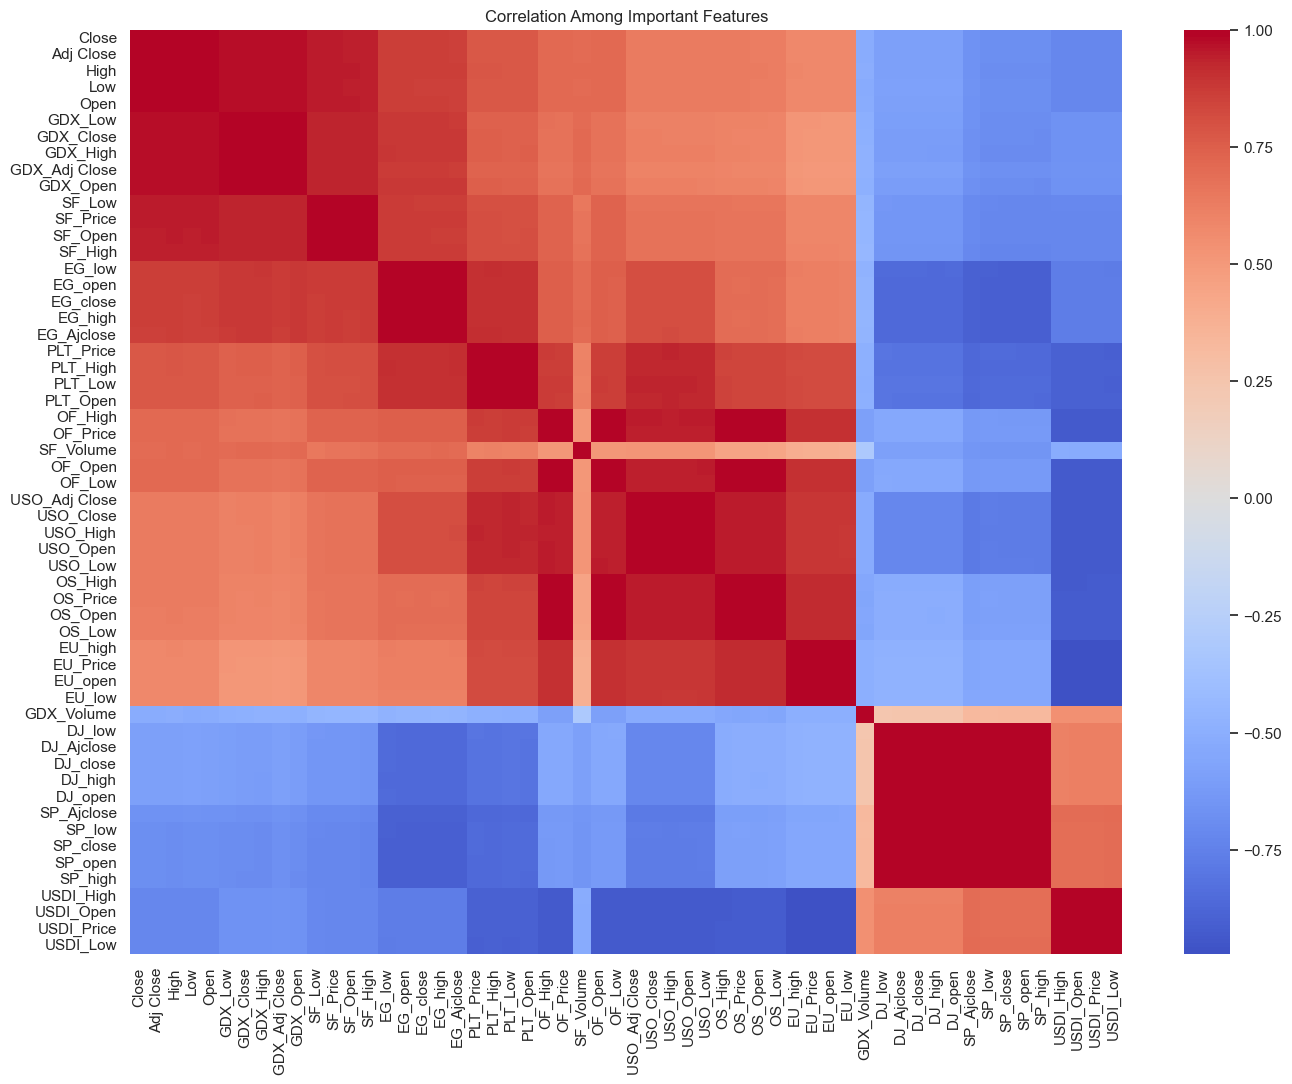

In [83]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    selected_corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Among Important Features")
plt.show()

The heatmap shows strong correlation among many selected independent variables. This is expected because several variables represent similar price information, such as open, high, low, close, and adjusted close values for the same asset. The presence of large red blocks indicates multicollinearity among feature groups. The blue regions show negative correlation, especially between the US Dollar Index related features and several gold or commodity-related features. Due to this multicollinearity, feature reduction or dimensionality reduction methods such as PCA can be considered during model training.

In [84]:
high_corr_pairs = []

for i in range(len(selected_corr.columns)):
    for j in range(i + 1, len(selected_corr.columns)):
        feature_1 = selected_corr.columns[i]
        feature_2 = selected_corr.columns[j]
        corr_value = selected_corr.iloc[i, j]

        if abs(corr_value) >= 0.9:
            high_corr_pairs.append((feature_1, feature_2, corr_value))

high_corr_pairs_df = pd.DataFrame(
    high_corr_pairs,
    columns=["feature_1", "feature_2", "correlation"]
)

print("Number of highly correlated feature pairs (|correlation| >= 0.9):", len(high_corr_pairs_df))

high_corr_pairs_df.sort_values("correlation", ascending=False).reset_index(drop=True)

Number of highly correlated feature pairs (|correlation| >= 0.9): 419


,feature_1,feature_2,correlation
0,Close,Adj Close,1.000000
1,USO_Adj Close,USO_Close,1.000000
2,DJ_Ajclose,DJ_close,1.000000
3,EG_close,EG_Ajclose,0.999940
4,USO_Adj Close,USO_Low,0.999879
...,...,...,...
414,EU_open,USDI_High,-0.971098
415,EU_Price,USDI_High,-0.971268
416,EU_high,USDI_Price,-0.971406
417,EU_high,USDI_Open,-0.971514


## Target Distribution

This plot shows the distribution of the value we want to predict: the next day adjusted closing price.

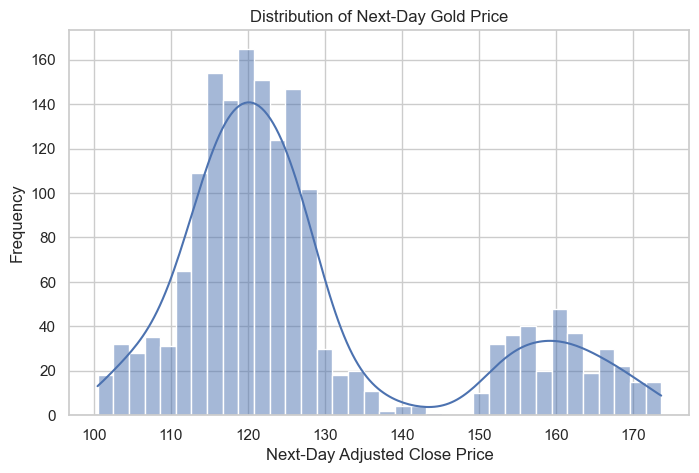

In [85]:
plt.figure(figsize=(8, 5))
sns.histplot(eda_df["target_next_price"], kde=True)
plt.title("Distribution of Next-Day Gold Price")
plt.xlabel("Next-Day Adjusted Close Price")
plt.ylabel("Frequency")
plt.show()

The target variable `target_next_price` is mostly concentrated between 110 and 130 USD, with another smaller cluster between 150 and 170 USD. The distribution is not perfectly normal and appears to have two price regimes. This reflects changes in gold price levels over different time periods.

## Current Price vs Next-Day Price

This scatter plot checks how strongly today's adjusted closing price is related to the next day's adjusted closing price.

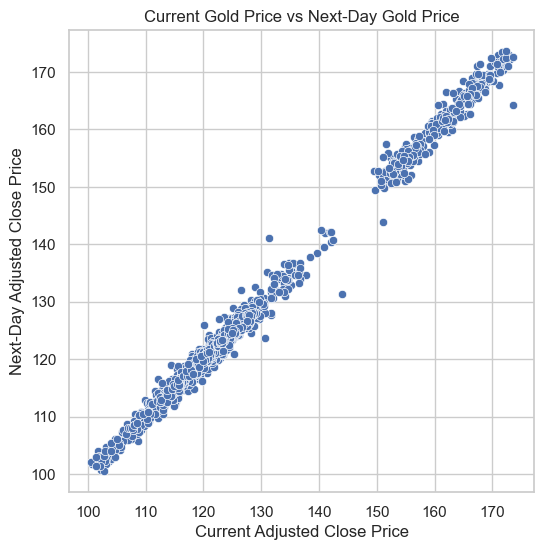

In [86]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=eda_df["Adj Close"],
    y=eda_df["target_next_price"]
)
plt.title("Current Gold Price vs Next-Day Gold Price")
plt.xlabel("Current Adjusted Close Price")
plt.ylabel("Next-Day Adjusted Close Price")
plt.show()

The scatter plot shows a strong positive linear relationship between the current adjusted closing price and the next-day adjusted closing price. Most points lie close to the diagonal pattern, indicating that today's gold price is a strong predictor of tomorrow's price. This is expected in financial time-series data, where prices usually change gradually from one day to the next. A few points deviate from the pattern, representing days with larger price changes.

## Daily Return Distribution

Even though the project predicts price, daily returns help us understand how volatile gold prices are from one day to the next.

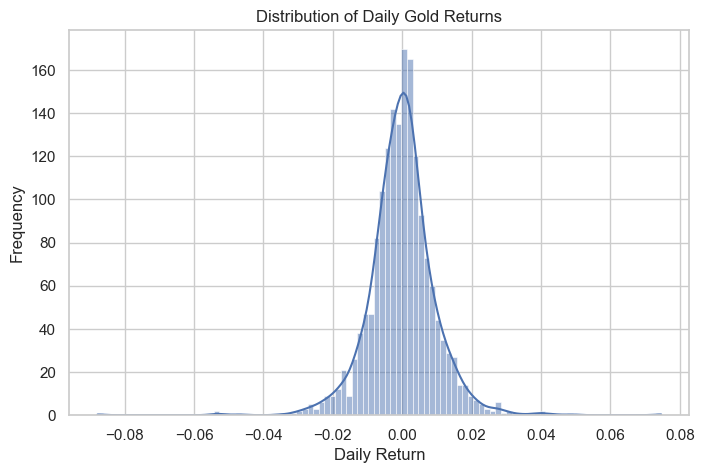

In [87]:
eda_df["gold_return_1d"] = eda_df["Adj Close"].pct_change()

plt.figure(figsize=(8, 5))
sns.histplot(eda_df["gold_return_1d"].dropna(), kde=True)
plt.title("Distribution of Daily Gold Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

The distribution of daily gold returns is centered around zero, showing that most daily price changes are small. The sharp peak indicates that gold prices usually move gradually from one day to the next. However, the tails on both sides show that occasional larger positive and negative movements occur. These extreme return values represent market volatility.

## Outlier Check for Numeric Features

In [88]:
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (
    (numeric_df < (Q1 - 1.5 * IQR)) |
    (numeric_df > (Q3 + 1.5 * IQR))
)

outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print("No of features with outliers:", (outlier_counts > 0).sum())

outlier_counts[outlier_counts > 0]

No of features with outliers: 34


Open                 326
High                 326
Low                  325
Close                325
Adj Close            325
target_next_price    324
GDX_Low              313
GDX_Adj Close        306
GDX_Close            306
GDX_High             304
GDX_Open             302
SF_Volume            234
RHO_PRICE            154
EG_volume             87
USDI_Volume           77
EG_open               74
SF_Price              73
EG_high               73
EG_low                72
SF_Low                72
SF_Open               68
EG_close              67
Volume                65
GDX_Volume            64
SF_High               62
EG_Ajclose            51
USO_Volume            46
SP_volume             42
OF_Volume             41
PLD_Price             29
PLD_Open              29
PLD_High              28
PLD_Low               25
DJ_volume             25
dtype: int64

In [89]:
outlier_percentage = (
    (outlier_counts / len(eda_df)) * 100
).sort_values(ascending=False)

outlier_percentage[outlier_percentage > 0]

Open                 18.986605
High                 18.986605
Low                  18.928363
Close                18.928363
Adj Close            18.928363
target_next_price    18.870122
GDX_Low              18.229470
GDX_Adj Close        17.821782
GDX_Close            17.821782
GDX_High             17.705300
GDX_Open             17.588818
SF_Volume            13.628422
RHO_PRICE             8.969132
EG_volume             5.066977
USDI_Volume           4.484566
EG_open               4.309843
SF_Price              4.251602
EG_high               4.251602
EG_low                4.193361
SF_Low                4.193361
SF_Open               3.960396
EG_close              3.902155
Volume                3.785673
GDX_Volume            3.727432
SF_High               3.610949
EG_Ajclose            2.970297
USO_Volume            2.679091
SP_volume             2.446127
OF_Volume             2.387886
PLD_Price             1.688992
PLD_Open              1.688992
PLD_High              1.630751
PLD_Low 

## Outlier Check for Important Features

In [90]:
selected_features = important_features["feature"].tolist()

important_numeric_df = eda_df[selected_features]

Q1 = important_numeric_df.quantile(0.25)
Q3 = important_numeric_df.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (
    (important_numeric_df < (Q1 - 1.5 * IQR)) |
    (important_numeric_df > (Q3 + 1.5 * IQR))
)

important_outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print("No of important features with outliers:", (important_outlier_counts > 0).sum())


important_outlier_counts[important_outlier_counts > 0]

No of important features with outliers: 21


Open             326
High             326
Close            325
Adj Close        325
Low              325
GDX_Low          313
GDX_Close        306
GDX_Adj Close    306
GDX_High         304
GDX_Open         302
SF_Volume        234
EG_open           74
SF_Price          73
EG_high           73
EG_low            72
SF_Low            72
SF_Open           68
EG_close          67
GDX_Volume        64
SF_High           62
EG_Ajclose        51
dtype: int64

In [91]:
important_outlier_percentage = (
    important_outlier_counts / len(eda_df) * 100
).sort_values(ascending=False)

important_outlier_percentage[important_outlier_percentage > 0]

Open             18.986605
High             18.986605
Close            18.928363
Adj Close        18.928363
Low              18.928363
GDX_Low          18.229470
GDX_Close        17.821782
GDX_Adj Close    17.821782
GDX_High         17.705300
GDX_Open         17.588818
SF_Volume        13.628422
EG_open           4.309843
SF_Price          4.251602
EG_high           4.251602
EG_low            4.193361
SF_Low            4.193361
SF_Open           3.960396
EG_close          3.902155
GDX_Volume        3.727432
SF_High           3.610949
EG_Ajclose        2.970297
dtype: float64

## Boxplot for top important features with most outliers

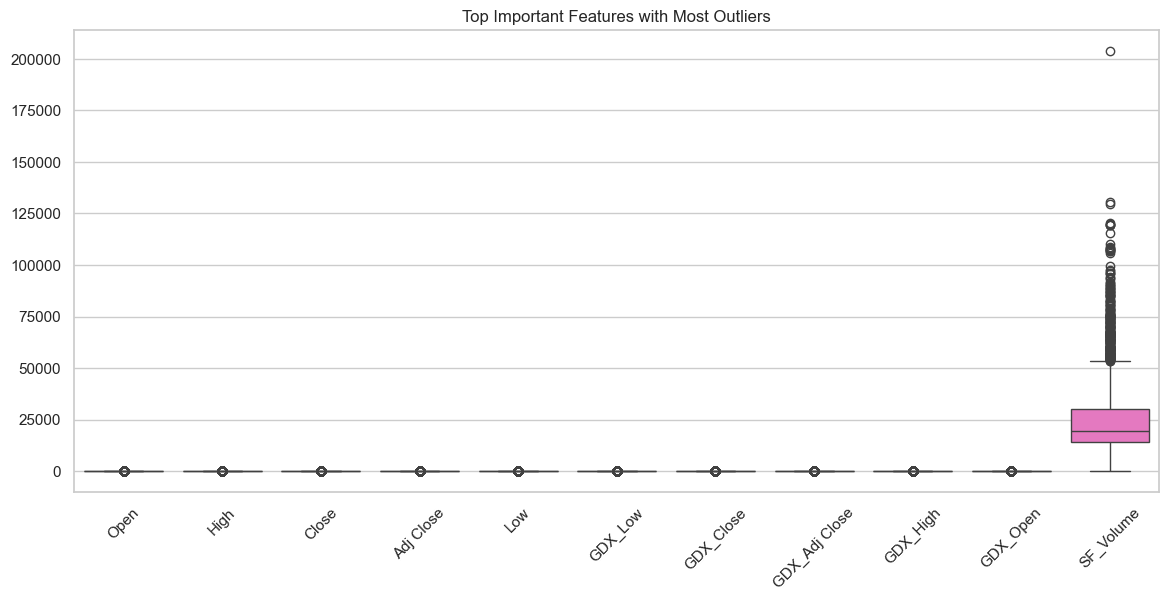

In [92]:
top_outlier_features = important_outlier_counts[
    important_outlier_counts > 0
].head(11).index

plt.figure(figsize=(14, 6))
sns.boxplot(data=eda_df[top_outlier_features])
plt.xticks(rotation=45)
plt.title("Top Important Features with Most Outliers")
plt.show()

The boxplot of the top 11 important features with the most outliers shows that `SF_Volume` has a much larger scale than the other features. Because of this, most price-based variables appear compressed near zero. This indicates that the selected features are measured on different scales, especially volume-based features compared to price-based features.

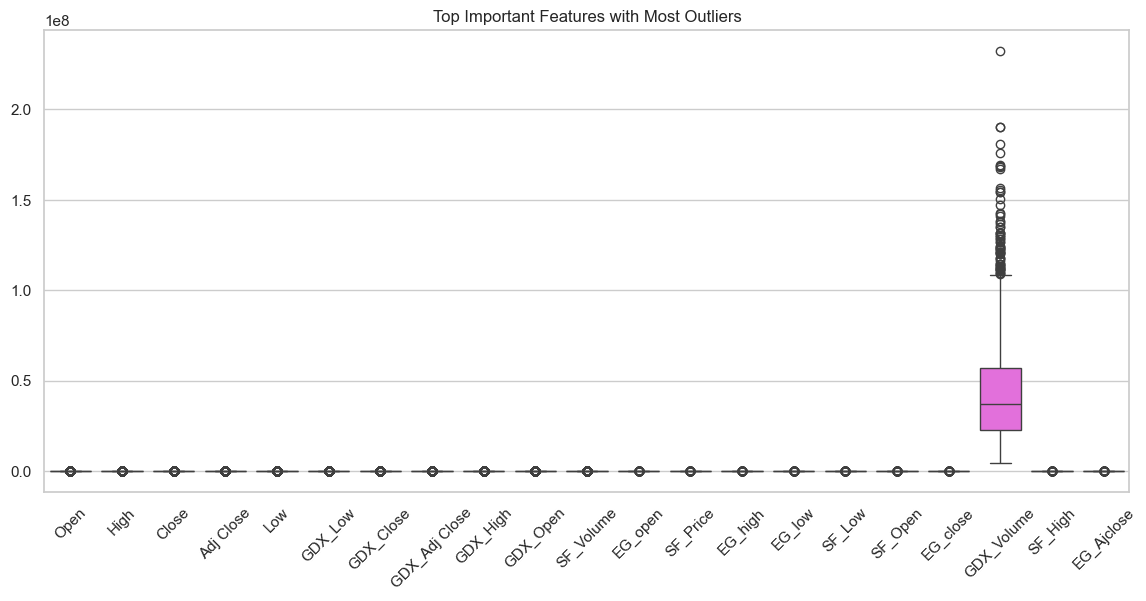

In [93]:
top_outlier_features = important_outlier_counts[
    important_outlier_counts > 0
].head(21).index

plt.figure(figsize=(14, 6))
sns.boxplot(data=eda_df[top_outlier_features])
plt.xticks(rotation=45)
plt.title("Top Important Features with Most Outliers")
plt.show()

When all 21 important features are plotted, `GDX_Volume` dominates the y-axis because its values are much larger than the other variables. This confirms that the scale issue is not limited to one column; volume-based features generally have much larger numerical ranges than price-based features.

## Standardisation

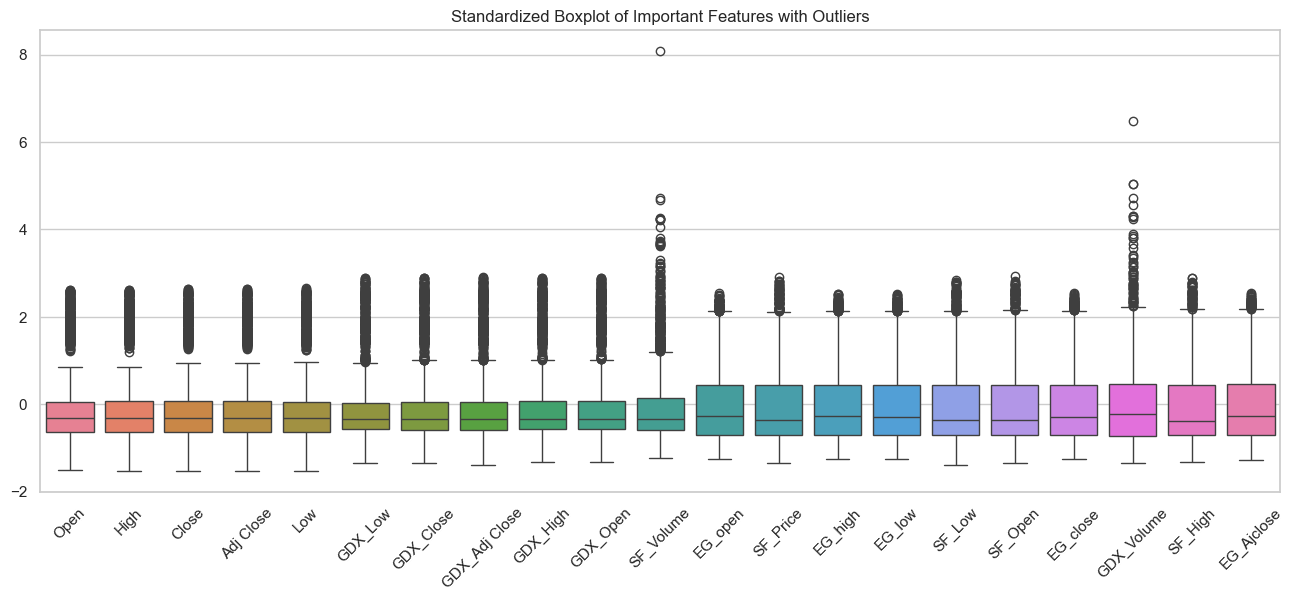

In [94]:
scaled_outlier_data = eda_df[top_outlier_features].copy()

scaled_outlier_data = (
    scaled_outlier_data - scaled_outlier_data.mean()
) / scaled_outlier_data.std()

plt.figure(figsize=(16, 6))
sns.boxplot(data=scaled_outlier_data)
plt.xticks(rotation=45)
plt.title("Standardized Boxplot of Important Features with Outliers")
plt.show()

After standardization, all important features are placed on a comparable scale. The boxplot shows that several features still contain outliers, especially volume-based features such as `SF_Volume` and `GDX_Volume`. Price-based features also show upper-side outliers, but their spread is more consistent. Since financial market data naturally contains sudden price movements and unusual trading volumes, these outliers are not removed during EDA.

In [97]:
processed_path = PROJECT_ROOT / "data" / "processed" / "gold_eda_data.csv"

eda_df.to_csv(processed_path, index=False)

print("Processed EDA dataset saved to:", processed_path)

Processed EDA dataset saved to: d:\Tanisha\MLDA\gold-price-prediction\data\processed\gold_eda_data.csv


In [98]:
selected_features_path = PROJECT_ROOT / "data" / "processed" / "selected_features.csv"

pd.DataFrame({"feature": selected_features}).to_csv(
    selected_features_path,
    index=False
)

print("Selected features saved to:", selected_features_path)

Selected features saved to: d:\Tanisha\MLDA\gold-price-prediction\data\processed\selected_features.csv
